<a href="https://colab.research.google.com/github/Purva2405/Image-Generator/blob/main/Image_Generator_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade diffusers transformers -q

In [ ]:
from pathlib import Path
import tqdm
import torch
import pandas as pd
import numpy as np
from diffusers import StableDiffusionPipeline
from transformers import pipeline, set_seed
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cv2

In [ ]:
import torch
class CFG:
  device = "cuda"
  seed = 42
  image_gen_steps = 35
  image_gen_model_id = "stabilityai/stable-diffusion-2"
  image_gen_size = (900, 900)
  image_gen_guidance_scale = 9
  prompt_gen_model_id = "gpt3"
  prompt_dataset_size = 6
  prompt_max_length = 12

  @classmethod
  def initialize_generator(cls):
    if cls.device == "cuda" and torch.cuda.is_available():
      cls.generator = torch.Generator(device='cuda').manual_seed(cls.seed)
    else:
      cls.generator = torch.Generator().manual_seed(cls.seed)

# Initialize the generator
CFG.initialize_generator()

In [ ]:
import torch
# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_gen_model = StableDiffusionPipeline.from_pretrained(
CFG.image_gen_model_id,
torch_dtype=torch.float,
revision="fp16",
use_auth_token='your_hugging_face_auth_token',
guidance_scale=9
)
# Move the model to the device
image_gen_model = image_gen_model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_loading_utils.py:333: FutureWarning: You are loading the variant fp16 from stabilityai/stable-diffusion-2 via `revision='fp16'`. This behavior is deprecated and will be removed in diffusers v1. One should use `variant='fp16'` instead. However, it appears that stabilityai/stable-diffusion-2 currently does not have the required variant filenames in the 'main' branch. 
 The Diffusers team and community would be very grateful if you could open an issue: https://github.com/huggingface/diffusers/issues/new with the title 'stabilityai/stable-diffusion-2 is missing fp16 files' so that the correct variant file can be added.
  warnings.warn(


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/602 [00:00<?, ?B/s]

Keyword arguments {'use_auth_token': 'your_hugging_face_auth_token', 'guidance_scale': 9} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-2/snapshots/d75b612d366d802b1753960de862a9270c8d55f1/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-2/snapshots/d75b612d366d802b1753960de862a9270c8d55f1/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
`torch_dtype` is deprecated! Use `dtype` instead!
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-2/snapshots/d75b612d366d802b1753960de862a9270c8d55f1/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-2/snapshots/d75b612d366d802b1753960de862a9270c8d55f1/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [ ]:
def generate_image(prompt, model):
  image = model(
    prompt, num_inference_steps=CFG.image_gen_steps,
    generator=CFG.generator,
    guidance_scale=CFG.image_gen_guidance_scale
  ).images[0]

  image = image.resize(CFG.image_gen_size)
  return image

  0%|          | 0/35 [00:00<?, ?it/s]

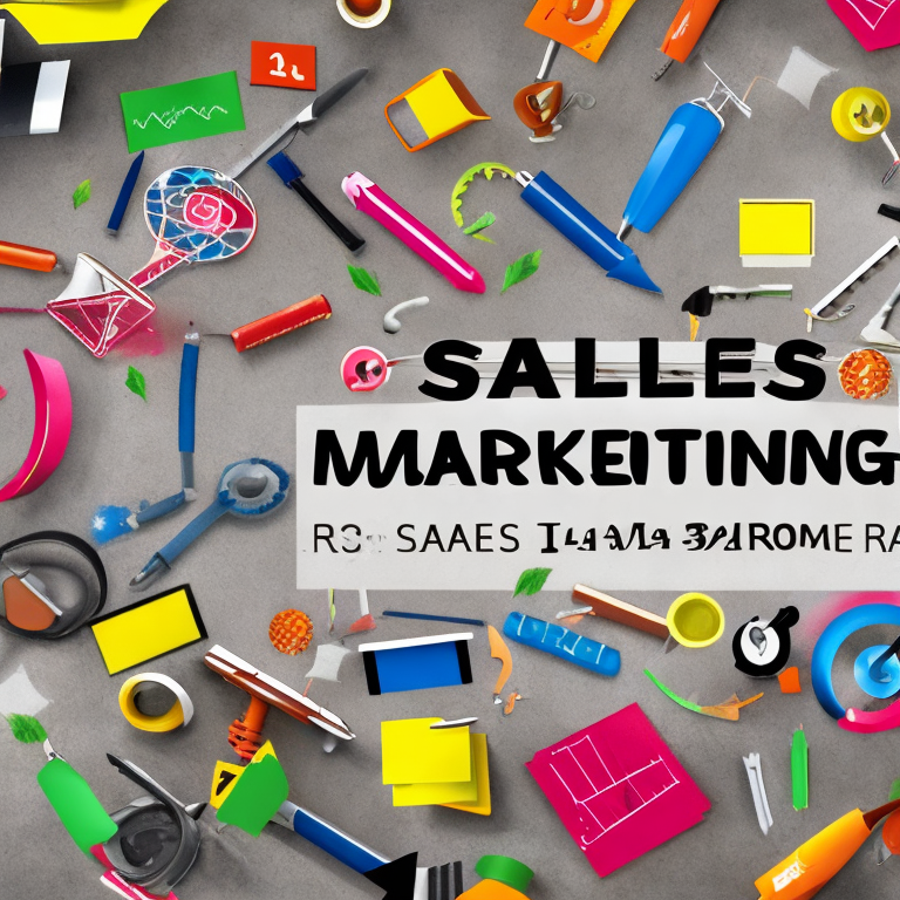

In [ ]:
generate_image("Sales Marketing backgroud", image_gen_model)

  0%|          | 0/35 [00:00<?, ?it/s]

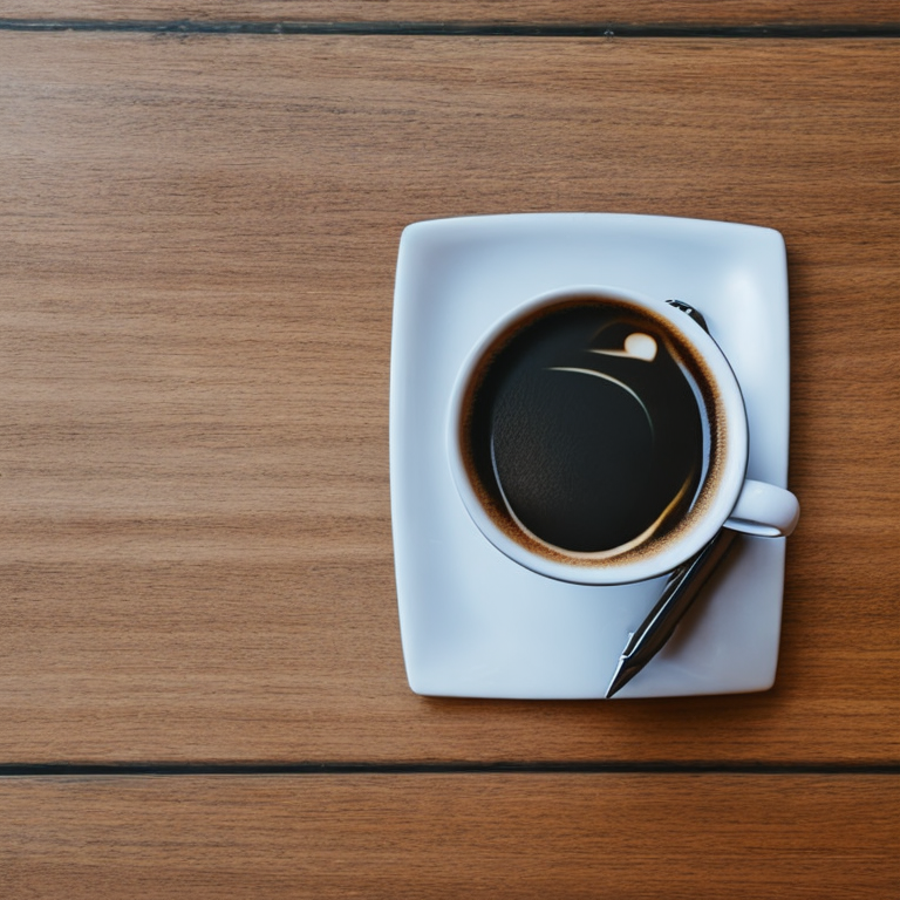

In [11]:
generate_image("coffee with pen and laptop at side on table", image_gen_model)